In [1]:
%pwd

'/home/tzuhsuan/GitHub/QFoam/High-fidelity-Rydberg-control-Z-gates-with-time-optimal-pulses/Manuscript-figures'

In [2]:
import os
import glob
import time
from IPython.display import clear_output

from qutip import *
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from rdquantum.pulse_shape import Saffman_shape
from rdquantum.fidelity import fidelity
from rdquantum.optimizer.de import de

# plt.rcParams["figure.figsize"] = [8, 5]
plt.rcParams["figure.figsize"] = [8, 6.75]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.linewidth"] = 2.50
plt.figure(dpi=1200)

<Figure size 9600x8100 with 0 Axes>

<Figure size 9600x8100 with 0 Axes>

In [3]:
op_pulse = []
out_init01 = []
out_init11 = []

# Add Gaussian500_53S_5L_BrrX
root_dir = "Gaussian500_53S_5L_BrrX"
data_dir_prefix = "Gaussian500_53S_5L_Brr"
brr = [50]
for i in range(len(brr)):
    op_pulse.append(np.load("../{}/{}{}/out-op_pulse.npz".format(root_dir, data_dir_prefix, brr[i]), allow_pickle=True))
    
    # popevo01
    out_init01_file = "../{}/{}{}/out_init01.npz".format(root_dir, data_dir_prefix, brr[i])
    out_init01.append(np.load(out_init01_file, allow_pickle=True))

    # popevo11
    out_init11_file = "../{}/{}{}/out_init11.npz".format(root_dir, data_dir_prefix, brr[i])
    out_init11.append(np.load(out_init11_file, allow_pickle=True))

brr_negative = [50]
for i in range(len(brr)):
    op_pulse.append(np.load("../{}/{}{}/out-op_pulse.npz".format(root_dir, data_dir_prefix, brr[i]), allow_pickle=True))
    
    # popevo01
    out_init01_file = "../{}/{}{}/out_init01_negative.npz".format(root_dir, data_dir_prefix, brr[i])
    out_init01.append(np.load(out_init01_file, allow_pickle=True))

    # popevo11
    out_init11_file = "../{}/{}{}/out_init11_negative.npz".format(root_dir, data_dir_prefix, brr[i])
    out_init11.append(np.load(out_init11_file, allow_pickle=True))
    
# # # Add Gaussian500_DeltaX
# root_dir = "Gaussian500_DeltaX"
# data_dir_prefix = "Gaussian500_Delta"
# delta_p = [3]
# for i in range(len(delta_p)):
#     op_pulse.append(np.load("../{}/{}{}/out-op_pulse.npz".format(root_dir, data_dir_prefix, delta_p[i]), allow_pickle=True))
    
#     # popevo01
#     out_init01_file = "../{}/{}{}/out_init01.npz".format(root_dir, data_dir_prefix, delta_p[i])
#     out_init01.append(np.load(out_init01_file, allow_pickle=True))

#     # popevo11
#     out_init11_file = "../{}/{}{}/out_init11.npz".format(root_dir, data_dir_prefix, delta_p[i])
#     out_init11.append(np.load(out_init11_file, allow_pickle=True))

In [4]:
pulse_Omega1 = []
pulse_Omega2 = []
pulse_Delta1 = []

for i in range(len(brr+brr_negative)):
    Omega1 = op_pulse[i]['Omega1']
    Omega2 = op_pulse[i]['Omega2']
    Delta1 = op_pulse[i]['Delta1']
    T_gate = op_pulse[i]['T_gate']
    
    Pulses = {'Omega1': Omega1, 'Omega2': Omega2, 
              'Delta1': Delta1, 
              'T_gate': T_gate}
    times = np.linspace(0.0, T_gate, 100)

    # Pulse shape
    T_gate = Pulses['T_gate'][0]         # (mu s) Total gate time
    n = 12   # Number of segments
    dt = T_gate/n       # (mu s) Duration of each segment

    def gaussian(t):
        # return Saffman_shape(t, Pulses['Omega1'], T_gate, n_seg)
        t = t % T_gate
        t0 = T_gate/2
        tau = 0.165*T_gate
        a = np.exp(- t0**2 / tau**2)
        return Pulses['Omega1'][0] * (np.exp(-(t-t0)**2 / tau**2) - a) / (1-a)

    pulse_Omega1_temp = []
    pulse_Omega2_temp = []
    pulse_Delta1_temp = []
    for t in times:
        pulse_Omega1_temp.append( gaussian(t))
        pulse_Omega2_temp.append( Omega2[0] )
        pulse_Delta1_temp.append( Delta1[0] )

    pulse_Omega1.append(pulse_Omega1_temp)
    pulse_Omega2.append(pulse_Omega2_temp)
    pulse_Delta1.append(pulse_Delta1_temp)

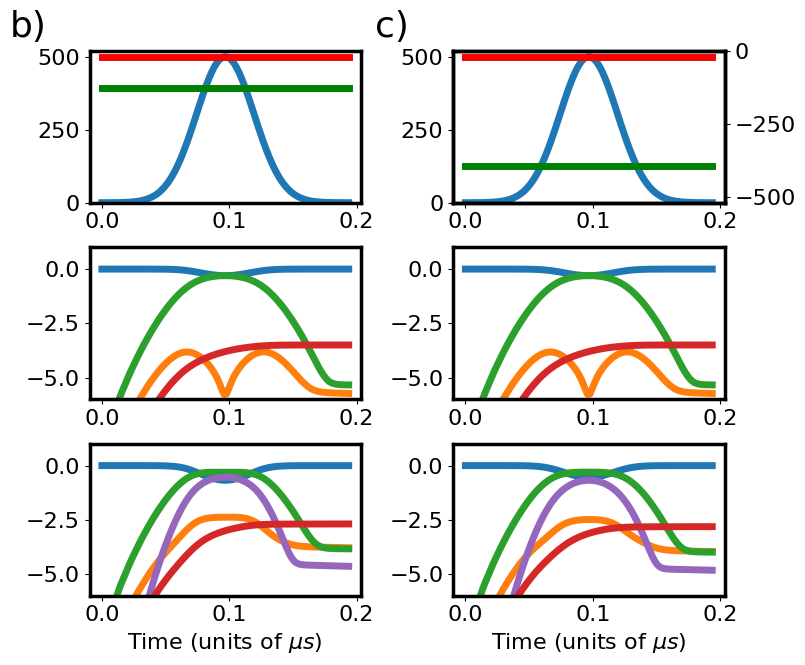

In [5]:
fig, axs = plt.subplots(3,2)

# axa = axs[0,0]
# axh = axs[0, 0]
# axi = axs[1, 0]
# axj = axs[2, 0]
axb = axs[0, 0]
axc = axs[1, 0]
axd = axs[2, 0]
axe = axs[0, 1]
axf = axs[1, 1]
axg = axs[2, 1]

xinterval = np.arange(0, 0.3, 0.1)
# xinterval = np.arange(0, 0.7, 0.3)
# b)
times = np.linspace(0.0, op_pulse[0]['T_gate'],  100)
#axb
axb.plot(times, pulse_Omega1[0], linewidth=5, label=r'$\Omega_p$')
axb.plot(times, pulse_Omega2[0], linewidth=5, label=r'$\Omega_r$', color='r')
axb.plot(times, pulse_Delta1[0], linewidth=5, label=r'$\Delta_p$', color='g')
# axb.legend(bbox_to_anchor=(.676, .425), fontsize=10)
# axb.set_ylabel(r'$\Omega(\Delta_p) / 2 \pi$' ' (units of MHz)', fontsize=16)
axb.set_ylim(0, 520)
axb.set_ylim(0, 520)
axb.set_xticks(xinterval)
yinterval = np.arange(0, 520, 250)
axb.set_yticks(yinterval)
axb.tick_params(axis='x', labelsize=16)
axb.tick_params(axis='y', labelsize=16)
# axb.set_title('a)', loc='left', pad=10, fontsize=26)
axb.set_title('b)', x=-0.225, pad=10, fontsize=26)


#axc
axc.plot(times, out_init01[0]["P01"], linewidth=5) 
axc.plot(times, out_init01[0]["P0p"], linewidth=5)
axc.plot(times, out_init01[0]["P0r"], linewidth=5)
axc.plot(times, out_init01[0]["P000d"], linewidth=5)
axc.set_ylim(-6, 1)
# axc.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=16) 
# axc.legend(("P01", "P0p", "P0r", "P000D"), fontsize=10)
axc.set_xticks(xinterval)
axc.tick_params(axis='x', labelsize=16)
axc.tick_params(axis='y', labelsize=16)
# axc.set_title('b)', loc='left', pad=10)

#axd
axd.plot(times, out_init11[0]["P11"], linewidth=5) 
axd.plot(times, out_init11[0]["Ppp"], linewidth=5)
axd.plot(times, out_init11[0]["P1rr1"], linewidth=5)
axd.plot(times, out_init11[0]["Prr"], linewidth=5, color='tab:purple')
axd.plot(times, out_init11[0]["P00dd"], linewidth=5, color='tab:red')
axd.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=16)
axd.set_ylim(-6, 1)
# axd.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=16) 
# axd.legend(("P11", "P" r"$'$" "pp", "P1rr1", "Prr", r"$\tilde{P}$""00DD"), fontsize=10)
axd.set_xticks(xinterval)
axd.tick_params(axis='x', labelsize=16)
axd.tick_params(axis='y', labelsize=16)
# axd.set_title('c)', loc='left', pad=10)


# c) negative
times = np.linspace(0.0, op_pulse[1]['T_gate'],  100)
#axe
axep = axe.plot(times, pulse_Omega1[1], linewidth=5, label=r'$\Omega_p$')
axep2 = axe.plot(times, pulse_Omega2[1], linewidth=5, label=r'$\Omega_r$', color='r')
axet = axe.twinx()
axetp = axet.plot(times, [-x for x in pulse_Delta1[1]], linewidth=5, label=r'$\Delta_p$', color='g')
axeld = axep + axep2 + axetp
axelb = [lb.get_label() for lb in axeld]
# axe.legend(axeld, axelb, bbox_to_anchor=(1.25, .825), fontsize=14)
# axe.legend(bbox_to_anchor=(1., .825), fontsize=14)

axe.set_ylim(0, 520)
axet.set_ylim(-520, 0)
axe.set_xticks(xinterval)
yinterval = np.arange(0, 520, 250)
y1interval = np.arange(-500, 20, 250)
axe.set_yticks(yinterval)
axet.set_yticks(y1interval)
axe.tick_params(axis='x', labelsize=16)
axe.tick_params(axis='y', labelsize=16)
axet.tick_params(axis='y', labelsize=16)
# axe.set_title('b)', loc='left', pad=10, fontsize=26)
axe.set_title('c)', x=-0.225, pad=10, fontsize=26)

#axf
axf.plot(times, out_init01[1]["P01"], linewidth=5) 
axf.plot(times, out_init01[1]["P0p"], linewidth=5)
axf.plot(times, out_init01[1]["P0r"], linewidth=5)
axf.plot(times, out_init01[1]["P000d"], linewidth=5)
# axf.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=12)
axf.set_ylim(-6, 1)
# axf.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=12) 
# axf.legend(("P01", "P0p", "P0r", "P000D"), bbox_to_anchor=(1., .925), fontsize=14)
axf.set_xticks(xinterval)
axf.tick_params(axis='x', labelsize=16)
axf.tick_params(axis='y', labelsize=16)
# axf.set_title('e)', loc='left', pad=10)

#axg
axg.plot(times, out_init11[1]["P11"], linewidth=5) 
axg.plot(times, out_init11[1]["Ppp"], linewidth=5)
axg.plot(times, out_init11[1]["P1rr1"], linewidth=5)
axg.plot(times, out_init11[1]["Prr"], linewidth=5, color='tab:purple')
axg.plot(times, out_init11[1]["P00dd"], linewidth=5, color='tab:red')
axg.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=16)
axg.set_ylim(-6, 1)
# axg.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=12) 
# axg.legend(("P11", "P" r"$'$" "pp", "P1rr1", "Prr", r"$\tilde{P}$""00DD"), bbox_to_anchor=(1., 1.175), fontsize=14)
axg.set_xticks(xinterval)
axg.tick_params(axis='x', labelsize=16)
axg.tick_params(axis='y', labelsize=16)
# axg.set_title('f)', loc='left', pad=10)


# # a)
# times = np.linspace(0.0, op_pulse[2]['T_gate'],  100)
# xinterval = np.arange(0, 0.82, 0.4)
# #axh
# axh.plot(times, pulse_Omega1[2], linewidth=5, label=r'$\Omega_p$')
# axh.plot(times, pulse_Omega2[2], linewidth=5, label=r'$\Omega_r$', color='r')
# axht = axh.twinx()
# axht.plot(times, [x//1000 for x in pulse_Delta1[2]], linewidth=5, label=r'$\Delta_p$', color='g')
# axh.set_ylabel(r'$\Omega / 2 \pi$' '\n' ' (units of MHz)', fontsize=16)
# # axht.set_ylabel(r'$\Delta_p / 2 \pi$' ' (units of GHz)', fontsize=16)
# axht.set_ylabel(r'$\Delta_p / 2 \pi$' ' (GHz)', fontsize=16)
# # axh.set_ylabel(r'$\Omega(\Delta_p) / 2 \pi$' '\n' ' (units of MHz)', fontsize=16)
# # axh.legend(bbox_to_anchor=(1., .425), fontsize=10)
# axh.set_ylim(0, 520)
# axht.set_ylim(0, 4, 1)
# axh.set_xticks(xinterval)
# yinterval = np.arange(0, 520, 250)
# axh.set_yticks(yinterval)
# axh.tick_params(axis='x', labelsize=16)
# axh.tick_params(axis='y', labelsize=16)
# axht.tick_params(axis='y', labelsize=16)
# axh.set_title('a)', x=-0.225, pad=10, fontsize=24)

# #axi
# axi.plot(times, out_init01[2]["P01"], linewidth=5) 
# axi.plot(times, out_init01[2]["P0p"], linewidth=5)
# axi.plot(times, out_init01[2]["P0r"], linewidth=5)
# axi.plot(times, out_init01[2]["P000d"], linewidth=5)
# # axi.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=12)
# axi.set_ylim(-6, 1)
# axi.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=16) 
# # axi.legend(("P01", "P0p", "P0r", "P000D"), bbox_to_anchor=(1., .475), fontsize=10)
# axi.set_xticks(xinterval)
# axi.tick_params(axis='x', labelsize=16)
# axi.tick_params(axis='y', labelsize=16)
# # axi.set_title('e)', loc='left', pad=10)

# #axj
# axj.plot(times, out_init11[2]["P11"], linewidth=5) 
# axj.plot(times, out_init11[2]["Ppp"], linewidth=5)
# axj.plot(times, out_init11[2]["P1rr1"], linewidth=5)
# axj.plot(times, out_init11[2]["Prr"], linewidth=5, color='tab:purple')
# axj.plot(times, out_init11[2]["P00dd"], linewidth=5, color='tab:red')
# axj.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=16)
# axj.set_ylim(-6, 1)
# axj.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=16) 
# # axj.legend(("P11", "P" r"$'$" "pp", "P1rr1", "Prr", r"$\tilde{P}$""00DD"), bbox_to_anchor=(1., .625), fontsize=10)
# axj.set_xticks(xinterval)
# # axj.set_title('f)', loc='left', pad=10)
# axj.tick_params(axis='x', labelsize=16)
# axj.tick_params(axis='y', labelsize=16)

plt.savefig('fig3_negative.png', dpi=1200)